In [ ]:
import pandas as pd
import numpy as np
import seaborn as sn
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df1=pd.read_csv("/content/customer_churn_1M.csv")
df1

,age,annual_income,dependents,tenure,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,churn
0,43,55085.25,1,2,0,67.20,144.39,1,1,1,0
1,18,60786.11,1,22,0,71.54,1602.22,2,0,1,0
2,38,73184.32,0,3,0,112.20,328.81,4,1,1,0
3,44,40923.78,1,6,0,107.49,643.45,3,1,1,0
4,45,36400.94,0,9,0,110.05,648.79,3,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
999995,25,21309.78,4,5,0,90.70,423.98,4,1,1,0
999996,22,164236.89,1,11,0,68.48,763.49,2,0,0,0
999997,44,34258.27,1,12,0,101.98,1322.83,3,0,1,0
999998,65,38687.93,0,24,0,60.36,1320.08,2,0,0,0


In [ ]:
df1.dependents.value_counts()

,count
dependents,
0,449368
1,359443
2,143783
3,38247
4,7714
5,1445


In [ ]:
df1.shape

(1000000, 11)

In [ ]:
df1.columns

Index(['age', 'annual_income', 'dependents', 'tenure', 'senior_citizen',
       'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service',
       'has_internet_service', 'churn'],
      dtype='object')

In [ ]:
X=df1[['age', 'annual_income', 'tenure', 'senior_citizen',
       'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service',
       'has_internet_service', 'churn']]

In [ ]:
y=df1['dependents']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer # Import SimpleImputer

# Handle missing values using imputation (e.g., mean imputation)
# Note: Ideally, imputation should be done before scaling. However, to fix the error
# within this cell and given the current state of X_train/X_test (already scaled),
# we apply imputation here.
imputer_for_train_test = SimpleImputer(strategy='mean')

# Impute X_train and X_test
X_train_imputed = imputer_for_train_test.fit_transform(X_train)
X_test_imputed = imputer_for_train_test.transform(X_test)

# Initialize PCA. Fit PCA on the imputed X_train and then transform both X_train and X_test.
pca_model_for_train_test = PCA(n_components=2)
X_train = pca_model_for_train_test.fit_transform(X_train_imputed)
X_test = pca_model_for_train_test.transform(X_test_imputed)

# For X_pca, if it's intended to be a PCA on the entire dataset 'X' independently,
# we need to impute 'X' and then fit a new PCA model.
# Use a separate imputer for the original X DataFrame to ensure correct fitting.
imputer_for_X = SimpleImputer(strategy='mean')
X_imputed = imputer_for_X.fit_transform(X)

# Fit a new PCA model on the imputed full dataset X
pca_model_for_X = PCA(n_components=2)
X_pca = pca_model_for_X.fit_transform(X_imputed)


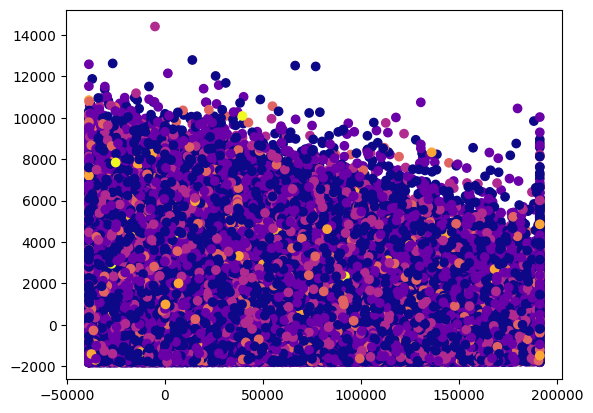

In [ ]:
plt.scatter(X_pca[:,0],X_pca[:,1],cmap='plasma',c=df1["dependents"])

In [ ]:
dataframe=pd.DataFrame(X_pca)
dataframe.head(4)

,0,1
0,-3703.038329,-1693.159067
1,1997.801323,-235.115490
2,14396.029131,-1508.332223
3,-17864.515258,-1194.146060


In [ ]:
## covariance is used to find the correlation between features
pca_model_for_X.get_covariance()[0]

array([ 1.25288824e+02,  4.20797484e+02,  3.79935480e-01, -2.82066639e-06,
        1.28864974e-01,  3.74100716e+01,  3.90645451e-03,  2.10689900e-04,
        9.37020830e-04, -1.00759106e-04])

In [ ]:
variance=pca_model_for_X.explained_variance_ratio_
variance

array([0.99757309, 0.00242616])

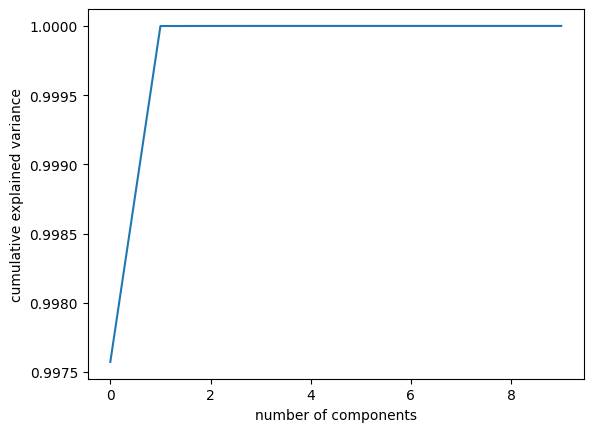

In [ ]:
pca = PCA().fit(X_imputed)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

In [ ]:
## we have reduced the features from 10 to 2
##afte thta u can use any model to build it

In [ ]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression()

In [ ]:
model1.fit(X_train, y_train)

LogisticRegression()

In [ ]:
model1.score(X_test, y_test)

0.449635

In [ ]:
model1.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_pred=model1.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[89927,     0,     0,     0,     0,     0],
       [72132,     0,     0,     0,     0,     0],
       [28592,     0,     0,     0,     0,     0],
       [ 7520,     0,     0,     0,     0,     0],
       [ 1553,     0,     0,     0,     0,     0],
       [  276,     0,     0,     0,     0,     0]])

<Axes: >

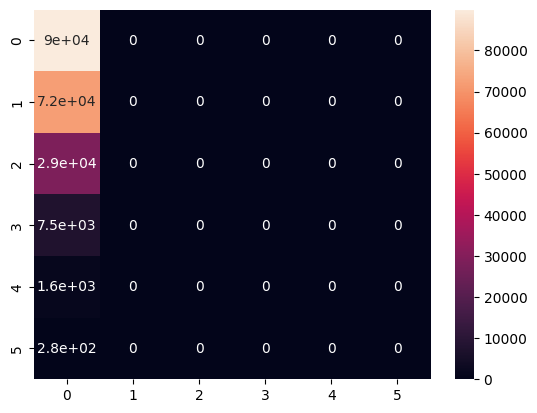

In [ ]:
sn.heatmap(cm,annot=True)

In [ ]:
## classification report

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rd=RandomForestClassifier()

In [ ]:
rd.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
rd.score(X_test,y_test)

0.3125

In [ ]:
## hyperparamter here